# MVP - Controle Estatístico da Qualidade aplicado ao consumo de energia elétrica

Este notebook é um **mínimo produto viável** para demonstrar uma aplicação prática de estatística estratégica e Controle Estatístico do Processo (CEP) em Python.

**Estudo de caso:** monitorar a variabilidade mensal do consumo de energia elétrica por consumidor em uma UF e classe de consumo, usando uma base pública de consumo de energia elétrica.

**Referencial:** o projeto se inspira em Montgomery, *Introdução ao Controle Estatístico da Qualidade*, especialmente na ideia de que melhoria da qualidade está ligada à redução da variabilidade e no uso de gráficos de controle para monitorar processos.

**Entregas do MVP:**
1. Carregar e validar a base de dados.
2. Fazer estatística descritiva e análise exploratória.
3. Construir um indicador operacional: `consumo_por_consumidor`.
4. Aplicar gráfico de controle I-MR.
5. Simular uma mudança no processo e detectar possíveis causas especiais.
6. Gerar conclusões e próximos passos para evolução do projeto.


## 1. Definição do problema

A base possui medições mensais de consumo de energia por UF e tipo de consumo. Como o consumo bruto tende a crescer com o número de consumidores, a análise utiliza um indicador normalizado:

$$
\text{consumo por consumidor} = \frac{\text{consumo}}{\text{número de consumidores}}
$$

Para manter o MVP simples e interpretável, o processo monitorado será:

* **UF:** DF
* **Tipo de consumo:** Residencial
* **Janela:** últimos 60 meses disponíveis

Essa escolha permite trabalhar com uma série mensal relativamente homogênea, evitando a mistura de realidades muito diferentes entre UFs e segmentos de consumo.


In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_CANDIDATES = [
    Path('dados/consumo_energia_eletrica.csv')
]

def find_data_path(candidates):
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        'Arquivo consumo_energia_eletrica.csv não encontrado. '        'No Colab, faça upload do CSV ou clone o repositório com a pasta data/.'
    )

DATA_PATH = find_data_path(DATA_CANDIDATES)
print(f'Base localizada em: {DATA_PATH}')


FileNotFoundError: Arquivo consumo_energia_eletrica.csv não encontrado. No Colab, faça upload do CSV ou clone o repositório com a pasta data/.

In [ ]:
# validação inicial
df_raw = pd.read_csv(DATA_PATH)

print('Dimensão original:', df_raw.shape)
display(df_raw.head())

df = df_raw.copy()

# Padronização de tipos
df['ano'] = pd.to_numeric(df['ano'], errors='coerce').astype('Int64')
df['mes'] = pd.to_numeric(df['mes'], errors='coerce').astype('Int64')
df['numero_consumidores'] = pd.to_numeric(df['numero_consumidores'], errors='coerce')
df['consumo'] = pd.to_numeric(df['consumo'], errors='coerce')
df['data'] = pd.to_datetime(dict(year=df['ano'], month=df['mes'], day=1), errors='coerce')

# Remoção de duplicatas
n_duplicadas = df.duplicated().sum()
df = df.drop_duplicates().sort_values(['data', 'sigla_uf', 'tipo_consumo']).reset_index(drop=True)

print('Linhas duplicadas removidas:', n_duplicadas)
print('Dimensão após limpeza:', df.shape)
print('Período:', df['data'].min().date(), 'até', df['data'].max().date())
print('UFs:', df['sigla_uf'].nunique())
print('Tipos de consumo:', sorted(df['tipo_consumo'].dropna().unique()))


Dimensão original: (39897, 6)


,ano,mes,sigla_uf,tipo_consumo,numero_consumidores,consumo
0,2004,1,TO,Total,NaN,65876
1,2004,1,BA,Total,NaN,1444451
2,2004,1,PR,Total,NaN,1596274
3,2004,1,RS,Total,NaN,1780912
4,2004,1,GO,Total,NaN,630624


Linhas duplicadas removidas: 1017
Dimensão após limpeza: (38880, 7)
Período: 2004-01-01 até 2023-12-01
UFs: 27
Tipos de consumo: ['Cativo', 'Comercial', 'Industrial', 'Outros', 'Residencial', 'Total']


In [ ]:
# criando um dicionário
dicionario = pd.DataFrame({
    'coluna': ['ano', 'mes', 'sigla_uf', 'tipo_consumo', 'numero_consumidores', 'consumo', 'data'],
    'interpretação': [
        'Ano de referência',
        'Mês de referência',
        'Unidade Federativa',
        'Classe ou visão de consumo',
        'Quantidade de consumidores informada para a classe',
        'Consumo mensal registrado',
        'Data mensal construída a partir de ano e mês'
    ]
})
display(dicionario)


,coluna,interpretação
0,ano,Ano de referência
1,mes,Mês de referência
2,sigla_uf,Unidade Federativa
3,tipo_consumo,Classe ou visão de consumo
4,numero_consumidores,Quantidade de consumidores informada para a cl...
5,consumo,Consumo mensal registrado
6,data,Data mensal construída a partir de ano e mês


In [ ]:
# aferindo a qualidade dos dados

qualidade = pd.DataFrame({
    'nulos': df.isna().sum(),
    'percentual_nulos': df.isna().mean() * 100,
    'tipo_python': df.dtypes.astype(str)
}).sort_values('percentual_nulos', ascending=False)

display(qualidade)

print('Quantidade de registros por tipo de consumo:')
display(df['tipo_consumo'].value_counts().to_frame('qtd_registros'))

print('Percentual de número de consumidores ausente por tipo de consumo:')
display((df.groupby('tipo_consumo')['numero_consumidores']
          .apply(lambda s: s.isna().mean() * 100)
          .sort_values(ascending=False)
          .to_frame('% nulos em numero_consumidores')))


,nulos,percentual_nulos,tipo_python
numero_consumidores,12960,33.3333,float64
mes,0,0.0000,Int64
ano,0,0.0000,Int64
sigla_uf,0,0.0000,object
tipo_consumo,0,0.0000,object
consumo,0,0.0000,int64
data,0,0.0000,datetime64[ns]


Quantidade de registros por tipo de consumo:


,qtd_registros
tipo_consumo,
Cativo,6480
Comercial,6480
Industrial,6480
Outros,6480
Residencial,6480
Total,6480


Percentual de número de consumidores ausente por tipo de consumo:


,% nulos em numero_consumidores
tipo_consumo,
Cativo,100.0000
Total,100.0000
Comercial,0.0000
Industrial,0.0000
Outros,0.0000
Residencial,0.0000


### Atenção metodológica importante

A coluna `tipo_consumo` possui categorias como `Total`, `Cativo`, `Residencial`, `Comercial`, `Industrial` e `Outros`. Por isso, **não é correto somar todas as linhas indiscriminadamente**, porque isso mistura totais e subcategorias e pode gerar dupla contagem.

Neste MVP:

- Para analisar o consumo agregado, use apenas `tipo_consumo == 'Total'`.
- Para analisar consumo por consumidor, use classes com `numero_consumidores` preenchido, como `Residencial`, `Comercial`, `Industrial` e `Outros`.


,count,mean,std,min,25%,50%,75%,max
numero_consumidores,"25,920.0000","682,303.3772","1,839,311.6874",52.0000,"18,956.5000","108,174.5000","442,412.0000","19,201,264.0000"
consumo,"38,880.0000","611,732.0067","1,208,066.8492",354.0000,"85,476.0000","221,062.0000","596,699.0000","12,809,742.0000"


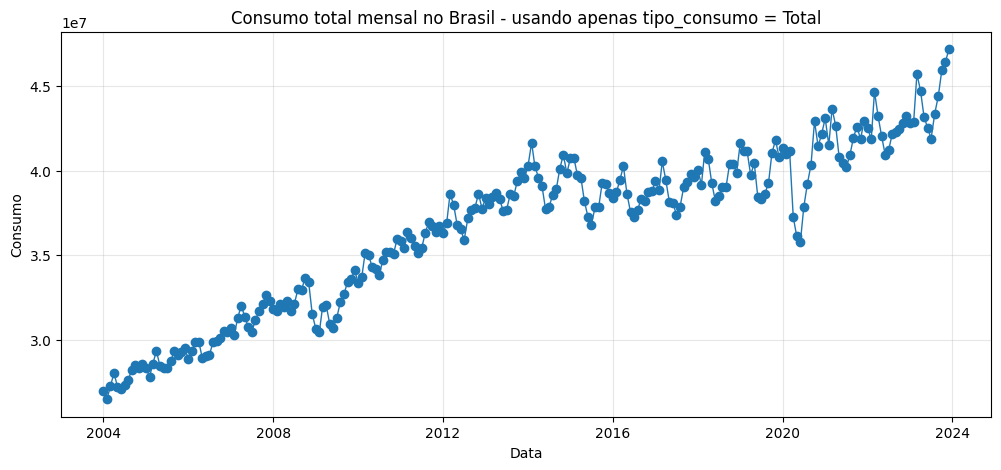

In [ ]:
# estatística descritiva

cols_numericas = ['numero_consumidores', 'consumo']
display(df[cols_numericas].describe().T)

# Consumo total nacional por mês, evitando dupla contagem
serie_total_brasil = (df[df['tipo_consumo'] == 'Total']
                      .groupby('data', as_index=True)['consumo']
                      .sum()
                      .sort_index())

plt.figure(figsize=(12, 5))
plt.plot(serie_total_brasil.index, serie_total_brasil.values, marker='o', linewidth=1)
plt.title('Consumo total mensal no Brasil - usando apenas tipo_consumo = Total')
plt.xlabel('Data')
plt.ylabel('Consumo')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# recorte do processo

UF_ESCOLHIDA = 'DF'
TIPO_ESCOLHIDO = 'Residencial'
JANELA_MESES = 60

processo = (df[(df['sigla_uf'] == UF_ESCOLHIDA) & (df['tipo_consumo'] == TIPO_ESCOLHIDO)]
            .dropna(subset=['numero_consumidores', 'consumo'])
            .sort_values('data')
            .copy())

processo['consumo_por_consumidor'] = processo['consumo'] / processo['numero_consumidores']
processo = processo.tail(JANELA_MESES).set_index('data')

print(f'Processo monitorado: {UF_ESCOLHIDA} - {TIPO_ESCOLHIDO}')
print('Período analisado:', processo.index.min().date(), 'até', processo.index.max().date())
print('Observações:', len(processo))

display(processo[['sigla_uf', 'tipo_consumo', 'numero_consumidores', 'consumo', 'consumo_por_consumidor']].head())
display(processo[['consumo', 'numero_consumidores', 'consumo_por_consumidor']].describe().T)


Processo monitorado: DF - Residencial


Período analisado: 2019-01-01 até 2023-12-01
Observações: 60


,sigla_uf,tipo_consumo,numero_consumidores,consumo,consumo_por_consumidor
data,,,,,
2019-01-01,DF,Residencial,"948,036.0000",187142,0.1974
2019-02-01,DF,Residencial,"948,666.0000",194454,0.2050
2019-03-01,DF,Residencial,"950,049.0000",183560,0.1932
2019-04-01,DF,Residencial,"948,560.0000",175562,0.1851
2019-05-01,DF,Residencial,"949,550.0000",194429,0.2048


,count,mean,std,min,25%,50%,75%,max
consumo,60.0000,"201,518.7833","14,078.0615","169,669.0000","193,120.5000","200,325.0000","209,970.2500","240,702.0000"
numero_consumidores,60.0000,"978,265.9500","26,224.2082","948,036.0000","951,701.2500","974,228.0000","1,003,790.2500","1,024,973.0000"
consumo_por_consumidor,60.0000,0.2059,0.0122,0.1787,0.1978,0.2044,0.2136,0.2348


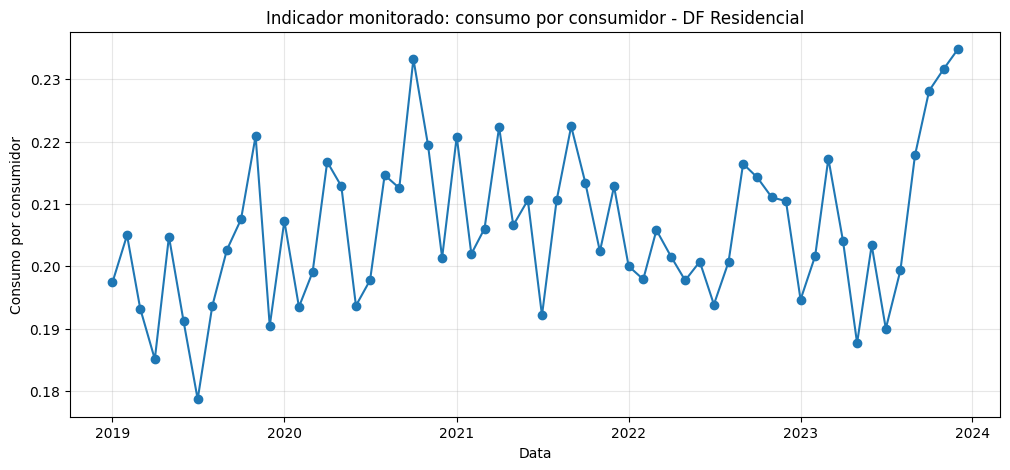

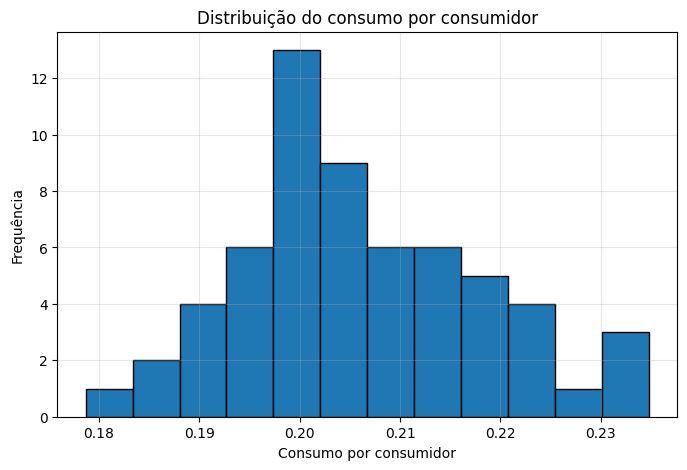

In [ ]:
# visualização do processo monitorado

plt.figure(figsize=(12, 5))
plt.plot(processo.index, processo['consumo_por_consumidor'], marker='o')
plt.title(f'Indicador monitorado: consumo por consumidor - {UF_ESCOLHIDA} {TIPO_ESCOLHIDO}')
plt.xlabel('Data')
plt.ylabel('Consumo por consumidor')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(processo['consumo_por_consumidor'], bins=12, edgecolor='black')
plt.title('Distribuição do consumo por consumidor')
plt.xlabel('Consumo por consumidor')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)
plt.show()


## 8. Gráfico de controle I-MR

O gráfico I-MR é usado quando há **observações individuais ao longo do tempo**. Ele possui duas partes:

- **I Chart:** monitora os valores individuais.
- **MR Chart:** monitora a amplitude móvel entre observações consecutivas.

Neste MVP, os limites são estimados por amplitude móvel média, usando a constante clássica `d2 = 1,128` para amplitude móvel de 2 observações.


In [ ]:
# função por CEP

def imr_limits(values):
    s = pd.Series(values).dropna().astype(float)
    if len(s) < 3:
        raise ValueError('São necessárias pelo menos 3 observações para estimar limites I-MR.')
    x = s.to_numpy()
    mr = np.abs(np.diff(x))
    mrbar = float(np.mean(mr))
    d2 = 1.128
    d4 = 3.267
    sigma = mrbar / d2 if mrbar > 0 else 0.0
    center = float(np.mean(x))
    return {
        'center': center,
        'sigma': sigma,
        'ucl_i': center + 3 * sigma,
        'lcl_i': center - 3 * sigma,
        'mrbar': mrbar,
        'ucl_mr': d4 * mrbar,
        'lcl_mr': 0.0,
    }


def basic_spc_flags(values, limits):
    s = pd.Series(values).dropna().astype(float)
    cl = limits['center']
    ucl = limits['ucl_i']
    lcl = limits['lcl_i']
    flags = pd.DataFrame(index=s.index)
    flags['valor'] = s
    flags['fora_limites'] = (s > ucl) | (s < lcl)

    # regra simples: 9 pontos consecutivos no mesmo lado da linha central
    side = np.where(s > cl, 1, np.where(s < cl, -1, 0))
    runs = []
    run = 0
    last = 0
    for val in side:
        if val != 0 and val == last:
            run += 1
        elif val != 0:
            run = 1
            last = val
        else:
            run = 0
            last = 0
        runs.append(run)
    flags['nove_mesmo_lado'] = np.array(runs) >= 9

    # regra simples: 6 pontos consecutivos crescendo ou decrescendo
    diff = s.diff().fillna(0)
    trend_runs = []
    run = 0
    last_sign = 0
    for d in diff:
        sign = 1 if d > 0 else (-1 if d < 0 else 0)
        if sign != 0 and sign == last_sign:
            run += 1
        elif sign != 0:
            run = 1
            last_sign = sign
        else:
            run = 0
            last_sign = 0
        trend_runs.append(run)
    flags['seis_tendencia'] = np.array(trend_runs) >= 5
    flags['alerta'] = flags[['fora_limites', 'nove_mesmo_lado', 'seis_tendencia']].any(axis=1)
    return flags


def plot_i_chart(series, limits, title):
    flags = basic_spc_flags(series, limits)
    plt.figure(figsize=(12, 5))
    plt.plot(series.index, series.values, marker='o', label='Observações')
    plt.axhline(limits['center'], linestyle='-', label='Linha central')
    plt.axhline(limits['ucl_i'], linestyle='--', label='LSC / UCL')
    plt.axhline(limits['lcl_i'], linestyle='--', label='LIC / LCL')
    alertas = flags[flags['alerta']]
    if not alertas.empty:
        plt.scatter(alertas.index, alertas['valor'], s=90, marker='x', label='Alertas')
    plt.title(title)
    plt.xlabel('Data')
    plt.ylabel(series.name or 'Valor')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    return flags


def plot_mr_chart(series, limits, title):
    mr = series.diff().abs().dropna()
    plt.figure(figsize=(12, 5))
    plt.plot(mr.index, mr.values, marker='o', label='Amplitude móvel')
    plt.axhline(limits['mrbar'], linestyle='-', label='MR médio')
    plt.axhline(limits['ucl_mr'], linestyle='--', label='LSC MR')
    plt.axhline(limits['lcl_mr'], linestyle='--', label='LIC MR')
    plt.title(title)
    plt.xlabel('Data')
    plt.ylabel('Amplitude móvel')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


Limites estimados para o gráfico I-MR:
center: 0.205930
sigma: 0.010035
ucl_i: 0.236034
lcl_i: 0.175826
mrbar: 0.011319
ucl_mr: 0.036980
lcl_mr: 0.000000


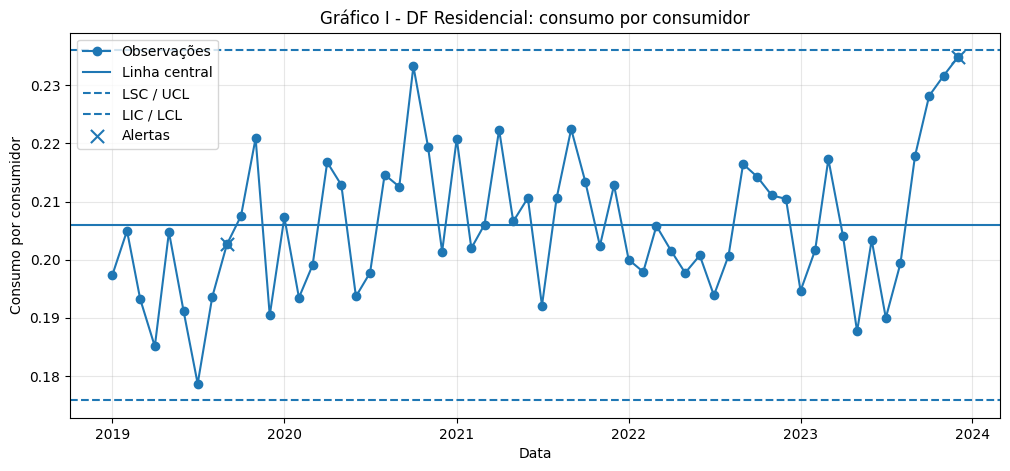

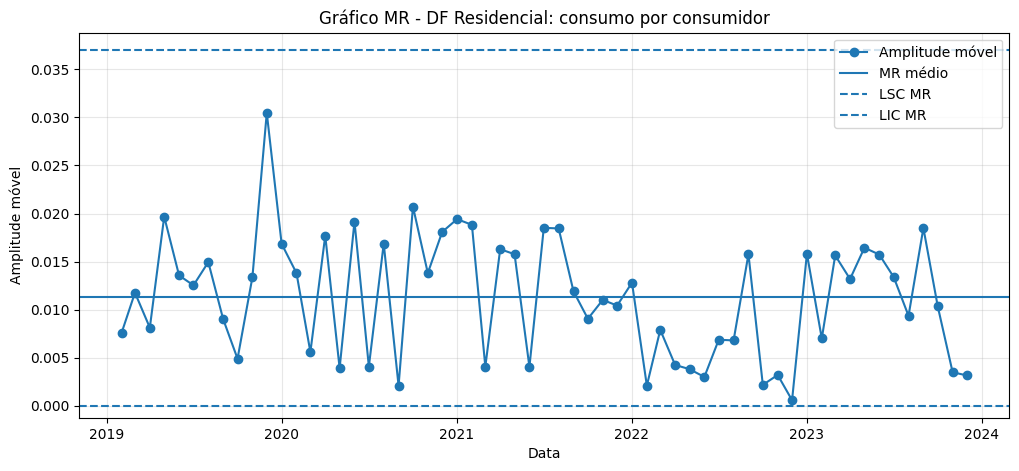

Alertas encontrados no processo real:


,valor,fora_limites,nove_mesmo_lado,seis_tendencia,alerta
data,,,,,
2019-09-01,0.2026,False,True,False,True
2023-12-01,0.2348,False,False,True,True


In [ ]:
# aplicação do gráfico I-MR ao processo real

serie_processo = processo['consumo_por_consumidor'].copy()
serie_processo.name = 'Consumo por consumidor'

limites = imr_limits(serie_processo)
print('Limites estimados para o gráfico I-MR:')
for k, v in limites.items():
    print(f'{k}: {v:.6f}')

flags_real = plot_i_chart(
    serie_processo,
    limites,
    f'Gráfico I - {UF_ESCOLHIDA} {TIPO_ESCOLHIDO}: consumo por consumidor'
)

plot_mr_chart(
    serie_processo,
    limites,
    f'Gráfico MR - {UF_ESCOLHIDA} {TIPO_ESCOLHIDO}: consumo por consumidor'
)

print('Alertas encontrados no processo real:')
display(flags_real[flags_real['alerta']])


## 10. Simulação de mudança no processo

Para atender ao requisito de simulação, vamos criar uma situação hipotética: nos últimos 6 meses, o consumo por consumidor aumenta 20%.

Essa mudança pode representar, por exemplo:

- alteração climática relevante;
- mudança de comportamento de consumo;
- erro de medição;
- alteração regulatória ou cadastral;
- outro fator especial que deslocou o processo.

O objetivo não é afirmar causalidade, mas mostrar como o CEP ajuda a **sinalizar pontos que merecem investigação**.


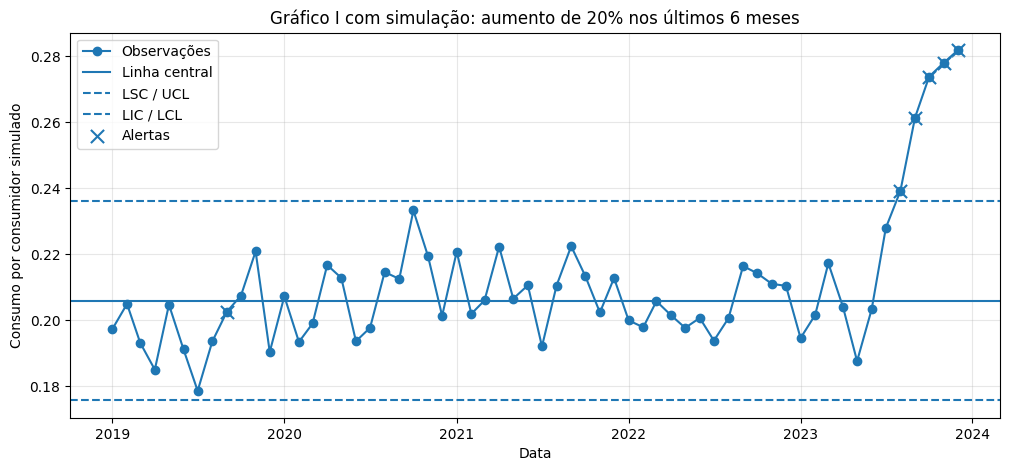

,real,simulado,diferença,diferença_%
data,,,,
2023-03-01,0.2173,0.2173,0.0000,0.0000
2023-04-01,0.2041,0.2041,0.0000,0.0000
2023-05-01,0.1877,0.1877,0.0000,0.0000
2023-06-01,0.2034,0.2034,0.0000,0.0000
2023-07-01,0.1900,0.2280,0.0380,20.0000
2023-08-01,0.1994,0.2392,0.0399,20.0000
2023-09-01,0.2178,0.2614,0.0436,20.0000
2023-10-01,0.2282,0.2738,0.0456,20.0000
2023-11-01,0.2317,0.2780,0.0463,20.0000


Alertas encontrados na simulação:


,valor,fora_limites,nove_mesmo_lado,seis_tendencia,alerta
data,,,,,
2019-09-01,0.2026,False,True,False,True
2023-08-01,0.2392,True,False,False,True
2023-09-01,0.2614,True,False,False,True
2023-10-01,0.2738,True,False,True,True
2023-11-01,0.2780,True,False,True,True
2023-12-01,0.2818,True,False,True,True


In [ ]:
# simulação de causa especial

serie_simulada = serie_processo.copy()
serie_simulada.iloc[-6:] = serie_simulada.iloc[-6:] * 1.20
serie_simulada.name = 'Consumo por consumidor simulado'

# mantemos os limites do processo real para testar a mudança simulada contra o padrão anterior.
flags_simulada = plot_i_chart(
    serie_simulada,
    limites,
    'Gráfico I com simulação: aumento de 20% nos últimos 6 meses'
)

comparacao = pd.DataFrame({
    'real': serie_processo,
    'simulado': serie_simulada,
    'diferença': serie_simulada - serie_processo,
    'diferença_%': (serie_simulada / serie_processo - 1) * 100,
})

display(comparacao.tail(10))

print('Alertas encontrados na simulação:')
display(flags_simulada[flags_simulada['alerta']])


## 11. Interpretação executiva

**O que o MVP já entrega:**

- Carregamento e validação da base.
- Tratamento de duplicatas.
- Atenção metodológica para evitar dupla contagem entre `Total` e subcategorias.
- Construção de indicador normalizado por consumidor.
- Estatística descritiva e visualização temporal.
- Gráfico de controle I-MR.
- Simulação de causa especial com detecção de alertas.

**Como interpretar:**

- Pontos dentro dos limites sugerem variação comum do processo.
- Pontos fora dos limites ou padrões não aleatórios sugerem causas especiais e pedem investigação.
- A simulação mostra que uma mudança artificial relevante é capturada pelo gráfico de controle.

**Limitações:**

- Consumo de energia tem tendência e sazonalidade; um modelo mais avançado poderia controlar esses efeitos.
- O uso de CEP aqui é didático e exploratório, não uma prova causal.
- Para análise profissional, seria recomendável separar UFs, tipos de consumo, sazonalidade e possíveis mudanças de política pública ou mercado.